# [STARE] MATHFI -- SPLIT TESTS #3 -- LOO AGG FOLD LOOPS -- seed 1337

In [1]:
import sys, os
sys.path.append(os.path.abspath('../../'))
sys.path.append(os.path.abspath('../../../FR-UNet/'))

print( os.getcwd())
sys.path


c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\notebooks\train_all


['C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\python310.zip',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\DLLs',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310\\lib',
 'C:\\Users\\s1005\\AppData\\Local\\Programs\\Python\\Python310',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv310',
 '',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\venv310\\lib\\site-packages',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation',
 'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\FR-UNet']

In [2]:
from src.models.unet import UNet
print(UNet)

<class 'src.models.unet.UNet'>


In [3]:
from pathlib import Path
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# CHANGE THESE

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 1337
DATASET = "STARE" # "DRIVE" | "STARE" | "CHASEDB1"

PATCH_SIZE = 128
VAL_WINDOW  = PATCH_SIZE
VAL_OVERLAP = 0.25

VESSEL_BIAS=0.7
MIN_PERCENT_VESSEL=0.008
V_MULT=30
DENSE_BIAS=None

IMG_SIZE=512

EPOCHS = 50
warmup_epochs = 5

FOLDS = 20

THRESHOLD_EVAL = 0.5


MODEL_NAME = "FR-UNet"
TITLE     = f"[{DATASET}] {MODEL_NAME} NEW SPLIT ({FOLDS} folds) -- seed 1337 -- DPCN 6x64 hl=2 reduce=64 cbam=16 epochs={EPOCHS}"
SAVE_ROOT = Path(f"../../../../pth/{MODEL_NAME}_{DATASET}_NEWSPLIT")     # a clean experiment folder
SAVE_CKPT = SAVE_ROOT / "checkpoints"
SAVE_PRED = SAVE_ROOT / "predictions"   # per-image logits/prob/masks
SAVE_VIZ  = SAVE_ROOT / "visuals"       # PNG overlays per test image
SAVE_LOGS = SAVE_ROOT / "logs"
for d in [SAVE_ROOT, SAVE_CKPT, SAVE_PRED, SAVE_VIZ, SAVE_LOGS]: d.mkdir(parents=True, exist_ok=True)

DATASET_ROOT        = f"../../../../Retinal_Vessel_Segmentation_Datasets/{DATASET}/"
DATASET_LABELFOLDER = "1st_manual"




# IMPORTS

In [5]:
import os, json, math, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt

# --- data utils ---
from src.data.splits import (
    split_drive_20_20,
    split_chase_subjectwise_20_8,
    split_stare_leave_one_out,
    stare_loo_fold,

    drive_random_20_20,

    chase_random_subject_split,

)

from src.data.dataloader import make_loaders
from src.data.augmentations import get_train_augs, get_val_augs

# use YOUR metrics utilities
from src.training.metrics import (
    confusion_counts,
    dice as dice_metric,
    iou as iou_metric,
    roc_auc as roc_auc_metric,
    pr_auc as pr_auc_metric,
    acc_from_counts,
    recall_from_counts,          # sensitivity
    specificity_from_counts,     # specificity
)



# --- evaluation & visualization ---
from src.evaluation.evaluate import evaluate_and_print
from src.evaluation.visualization import visualize_samples

In [ ]:
def eval_leftout_with_fov(prob_1chw: torch.Tensor,
                          gt_1chw: torch.Tensor,
                          fov_1chw: torch.Tensor,
                          thr: float = 0.5) -> dict:
    """
    Evaluate one test image (left out) using *your* metrics helpers.
    All metrics are computed *within FOV*.
    """
    # to cpu numpy
    p = prob_1chw.squeeze().detach().cpu().numpy()       # [H,W] probs in [0,1]
    g = gt_1chw.squeeze().detach().cpu().numpy()         # [H,W] {0,1}
    f = fov_1chw.squeeze().detach().cpu().numpy()        # [H,W] {0,1}

    # clamp to FOV (zero-out everything outside)
    p_f = p * (f > 0.5)
    g_f = (g > 0.5).astype(np.uint8)

    # binarize at thr (inside FOV)
    pred_f = (p_f >= thr).astype(np.uint8)

    # counts + derived metrics
    tp, fp, tn, fn = confusion_counts(pred_f, g_f)

    ACC  = float(acc_from_counts(tp, fp, tn, fn))
    SEN  = float(recall_from_counts(tp, fn))        # sensitivity / TPR
    SPE  = float(specificity_from_counts(tn, fp))
    DICE = float(dice_metric(pred_f, g_f))
    IOU  = float(iou_metric(pred_f, g_f))

    # probability-based (AUCs) computed on FOV-masked prob/gt
    try:
        AUC = float(roc_auc_metric(p_f, g_f))
    except Exception:
        AUC = float("nan")
    try:
        AP = float(pr_auc_metric(p_f, g_f))
    except Exception:
        AP = float("nan")

    return dict(ACC=ACC, Dice=DICE, IoU=IOU, SEN=SEN, SPE=SPE, AUC=AUC, AP=AP,
                tp=int(tp), fp=int(fp), tn=int(tn), fn=int(fn))



# helpers and config

In [7]:
os.getcwd()

'c:\\Users\\s1005\\OneDrive\\文件\\PLM_DOCS\\code\\githubs\\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\\notebooks\\train_all'

In [ ]:
# --- model factory (fresh per fold) ---
from src.models.wrappers.dpcn_concat_unet import DPCNConcatUNet
BASE_KW = {"cbam_reduction": 16}

def make_model(MODEL_NAME, train_loader = None) -> nn.Module:
    if MODEL_NAME == "MATHFI":
        # --- loss ---
        from src.training.loss_functions import DiceBCEComplementLoss

        def estimate_class_weights(loader, max_batches=20):
            with torch.no_grad():
                s = 0.0; n = 0
                for i, b in enumerate(loader):
                    s += b["mask"].float().mean().item(); n += 1
                    if i+1 >= max_batches: break
            p = max(1e-6, min(1-1e-6, s / max(1, n)))
            w1 = 1.0 / p; w0 = 1.0 / (1.0 - p)
            s2 = w0 + w1; w0 = 2.0 * w0 / s2; w1 = 2.0 * w1 / s2
            return w0, w1
        
        w0, w1 = estimate_class_weights(train_loader, max_batches=20)
        loss_fn = DiceBCEComplementLoss(w0=w0, w1=w1, dice_weight=0.5, bce_weight=0.5,
                                        exact_equation=False, reduction="mean")
        
        # --- model ---
        return DPCNConcatUNet(
            in_ch=1, enh_channels=64, iters=6,
            threshold_mode="scaled_vat", half_life=2.0,
            reduce_to=64, base_kwargs=BASE_KW
        ).to(DEVICE), loss_fn

    elif MODEL_NAME == "FR-UNet":
        loss_fn = nn.BCEWithLogitsLoss()
        from models.fr_unet import FR_UNet
        return FR_UNet().to(DEVICE), loss_fn
        
@torch.no_grad()
def sliding_window_forward_logits(model, img_1chw, window, overlap, device="cuda"):
    """
    img_1chw: torch.Tensor [1,1,H,W] on *any* device.
    Returns: averaged logits [1,1,H,W] on 'device'
    """
    model.eval()
    img = img_1chw.to(device, non_blocking=True)
    _, _, H, W = img.shape
    step = max(1, int(window * (1 - overlap)))

    # we'll average *logits* to keep your loss_fn (e.g., BCEWithLogits) unchanged
    acc  = torch.zeros_like(img, device=device)
    norm = torch.zeros_like(img, device=device)

    for y0 in range(0, max(1, H - window + 1), step):
        for x0 in range(0, max(1, W - window + 1), step):
            y1 = min(y0 + window, H); x1 = min(x0 + window, W)
            y0 = y1 - window;         x0 = x1 - window
            tile = img[:, :, y0:y1, x0:x1]                     # [1,1,win,win]
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                logit = model(tile)                            # [1,1,win,win]
            acc[:, :, y0:y1, x0:x1] += logit
            norm[:, :, y0:y1, x0:x1] += 1.0

    logits = acc / torch.clamp_min(norm, 1.0)
    return logits

@torch.no_grad()
def infer_full_logits(model: nn.Module, img_1chw: torch.Tensor, device=DEVICE, window=VAL_WINDOW, overlap=VAL_OVERLAP):
    model.eval()
    return sliding_window_forward_logits(model, img_1chw, window=window, overlap=overlap, device=device)


def add_metrics(model, root, label_folder, img_size, ckpt_path, threshold_eval, all_metrics):
        stem = Path(ckpt_path).stem  # "STARE_fold00"
        fold_id = int(stem.split("fold")[-1])  # 0
        print(f"checkpoint_path: {ckpt_path}\nfold_id:{fold_id}")

        _, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)
        
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        batch = next(iter(test_loader))
        x   = batch["image"].to(DEVICE)
        y   = batch["mask"].to(DEVICE)
        fov = batch.get("fov", torch.ones_like(y)).to(DEVICE)
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem

        logits = infer_full_logits(model, x, window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE)
        prob   = torch.sigmoid(logits)
        # binm   = (prob >= threshold_eval).float()

        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = eval_leftout_with_fov(prob[0,0], y[0,0], fov[0,0], thr=threshold_eval)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)

        def _fmt(v):  # pretty-print, handles NaN
            try:
                return f"{v:.4f}" if v == v else "nan"
            except Exception:
                return str(v)

        print(
            f"[F{fold_id:02d}] {img_stem}  ->  "
            + " ".join([f"{k}={_fmt(m[k])}" for k in ["ACC","Dice","IoU","SEN","SPE","AUC"]])
        )


# --- tiny metric collector (use yours if evaluate_and_print returns a dict) ---
from sklearn.metrics import roc_auc_score, average_precision_score


# --- DATASET HYPERPARAM SCHEDULERS ---
def sched_vessel_bias(epoch):
    if epoch <= 10: return 0.70
    if epoch <= 35: return 0.60
    return 0.50

def sched_min_percent_vessel(epoch):
    if epoch <= 10: return 0.008
    if epoch <= 35: return 0.010
    return 0.008

def sched_patch_size(epoch):
    return 160 if epoch > 45 else 128

# ---- single updater ----
def update_dataset(ds, epoch):
    ds.vessel_bias_p      = sched_vessel_bias(epoch)
    ds.min_percent_vessel = sched_min_percent_vessel(epoch)
    ds.patch_size         = sched_patch_size(epoch)

    
# --- training boilerplate (pass FOV into the model so DPCN can clamp each iter) ---
def train_one_epoch(model, loader, optimizer, scaler, loss_fn, device=DEVICE):
    model.train()
    total, n = 0.0, 0
    for batch in loader:
        x   = batch["image"].to(device, non_blocking=True)
        y   = batch["mask"].to(device,  non_blocking=True)
        fov = batch.get("fov", torch.ones_like(y)).to(device, non_blocking=True)

        # restrict labels to FOV (keeps loss fair)
        y = y * (fov > 0.5).float()

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
            if model.uses_fov: logits = model(x, fov=fov)          # << pass FOV so DPCN uses it
            else: logits = model(x)
            loss   = loss_fn(logits, y)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()

        total += loss.item() * x.size(0); n += x.size(0)
    return total / max(1, n)

@torch.no_grad()
def validate_loss_only(model, loader, loss_fn,  window, overlap, device=DEVICE,):
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        x   = batch["image"].to(device, non_blocking=True)
        y   = batch["mask"].to(device,  non_blocking=True)
        fov = batch.get("fov", torch.ones_like(y)).to(device, non_blocking=True)

        for i in range(x.size(0)):
            logits_i = infer_full_logits(model, x[i:i+1], device=device, window=window, overlap=overlap)
            yi = y[i:i+1] * (fov[i:i+1] > 0.5).float()
            with torch.amp.autocast(device_type="cuda", enabled=(device=="cuda")):
                loss_i = loss_fn(logits_i, yi)
            total += loss_i.item(); n += 1
    return total / max(1, n)

def atomic_torch_save(state, path: Path):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".partial")
    try: tmp.unlink()
    except FileNotFoundError: pass
    with open(tmp, "wb") as f:
        torch.save(state, f); f.flush(); os.fsync(f.fileno())
    os.replace(tmp, path)



# MAIN RUN

In [ ]:
# --- main LOO run ---
def run_stare_loo_experiment(
    root=DATASET_ROOT, label_folder=DATASET_LABELFOLDER, epochs=EPOCHS, warmup=warmup_epochs,
    batch_size=2, img_size=512, patch_train=True, patch_size=PATCH_SIZE, vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL, folds=FOLDS, fold_id=0, chckpnt_paths=None
):  
    rng = np.random.RandomState(SEED)
    all_metrics = []
    per_image_preds = {}   # img_stem -> dict(prob_path, bin_path, fold_id)
    
    while fold_id < folds:
        print(f"\n========== {DATASET} NEW SPLIT, Fold {fold_id+1}/{folds} ==========")

            
        # 1) split
        tr_pairs, te_pairs = stare_loo_fold(root, label_folder=label_folder, fold_id=fold_id)
        # 2) carve val deterministically from the 19 train images (e.g., last 3)
        val_pairs = tr_pairs[-3:]
        tr_pairs_ = tr_pairs[:-3]

        # 3) loaders
        train_loader, val_loader = make_loaders(
            train_pairs=tr_pairs_, val_pairs=val_pairs,
            image_size=img_size, batch_size=batch_size, num_workers=1,
            seed=SEED + fold_id, strict_fov=True,
            augs_train=get_train_augs(img_size),
            augs_val=get_val_augs(img_size),
            patch_train=patch_train, patch_size=patch_size,
            vessel_bias_p=vessel_bias_p, virtual_mult=100
        )
        _, test_loader = make_loaders(
            train_pairs=te_pairs, val_pairs=te_pairs,
            image_size=img_size, batch_size=1, num_workers=1,
            seed=SEED, strict_fov=True,
            augs_train=None, augs_val=get_val_augs(img_size),
        )

        # 4) model & optimizer
        model, loss_fn = make_model(MODEL_NAME, train_loader)
        model.uses_fov = MODEL_NAME == "MATHFI"     # whether to pass fov in forward or not

        # add checkpoint paths to metric list
        if fold_id == 0 and chckpnt_paths:
            for ckpt in chckpnt_paths:
                add_metrics(model, 
                            DATASET_ROOT, 
                            DATASET_LABELFOLDER,
                            img_size, ckpt, 
                            threshold_eval, all_metrics) 


        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        scaler    = torch.amp.GradScaler("cuda", enabled=(DEVICE=="cuda"))
        def lr_lambda(e):
            if e < warmup: return (e+1)/max(1, warmup)
            progress = (e - warmup) / max(1, epochs - warmup)
            return 0.5 * (1 + math.cos(math.pi * progress))
        scheduler = LambdaLR(optimizer, lr_lambda)

        # 5) train with best-val checkpointing
        best_val = float("inf")
        ckpt_path = SAVE_CKPT / f"{DATASET}_fold{fold_id:02d}.pth"

        train_losses, val_losses = [], []

        for ep in range(1, epochs+1):
            update_dataset(train_loader.dataset, ep)
            t0=time.time()
            tr_loss  = train_one_epoch(model, train_loader, optimizer, scaler, loss_fn)
            val_loss = validate_loss_only(model, val_loader, loss_fn, PATCH_SIZE, VAL_OVERLAP)
            scheduler.step()
            print(f"[F{fold_id:02d} E{ep:03d}] train={tr_loss:.4f} val={val_loss:.4f} "
                  f"lr={optimizer.param_groups[0]['lr']:.2e} time={(time.time()-t0):.1f}s")
            
            
            train_losses.append(float(tr_loss))
            val_losses.append(float(val_loss))

            if val_loss < best_val:
                best_val = val_loss
                atomic_torch_save(model.state_dict(), ckpt_path)
                print(f"\tCHECKPOINT SAVED: {ckpt_path}")
        
        plt.figure(figsize=(6,3.5))
        plt.plot(range(1, len(train_losses)+1), train_losses, label="train")
        plt.plot(range(1, len(val_losses)+1),   val_losses,   label="val")
        plt.xlabel("epoch"); plt.ylabel("loss"); plt.grid(True); plt.legend()
        plt.title("Train vs Val Loss:" + TITLE)
        plt.tight_layout()
        plt.show()

        # 6) eval on left-out image using best checkpoint

        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
        model.eval()

        batch = next(iter(test_loader))
        x   = batch["image"].to(DEVICE)
        y   = batch["mask"].to(DEVICE)
        fov = batch.get("fov", torch.ones_like(y)).to(DEVICE)
        img_path = batch["image_path"][0]
        img_stem = Path(img_path).stem

        logits = infer_full_logits(model, x, window=VAL_WINDOW, overlap=VAL_OVERLAP, device=DEVICE)
        prob   = torch.sigmoid(logits)
        binm   = (prob >= threshold_eval).float()

        # 6a) metrics
        # 6a) metrics — use YOUR metrics module via our wrapper
        m = eval_leftout_with_fov(prob[0,0], y[0,0], fov[0,0], thr=threshold_eval)
        m["fold_id"]  = fold_id
        m["image_id"] = img_stem
        all_metrics.append(m)

        def _fmt(v):  # pretty-print, handles NaN
            try:
                return f"{v:.4f}" if v == v else "nan"
            except Exception:
                return str(v)

        print(
            f"[F{fold_id:02d}] {img_stem}  ->  "
            + " ".join([f"{k}={_fmt(m[k])}" for k in ["ACC","Dice","IoU","SEN","SPE","AUC"]])
        )


        # 6b) save predictions
        SAVE_FILE = SAVE_PRED / f"{img_stem}__fold{fold_id:02d}.pt"
        torch.save({"logits": logits.cpu(), "prob": prob.cpu(), "bin": binm.cpu(),
                    "image_path": img_path, "fold": fold_id},
                  SAVE_FILE)
        per_image_preds[img_stem] = dict(
            prob_path=str((SAVE_PRED / f"{img_stem}__fold{fold_id:02d}.pt").as_posix()),
            fold_id=fold_id
        )

        print(f"== Predictions SAVED TO FILE: {SAVE_FILE} ==")

        # 6c) quick visualization panel for this test image
        fig, axs = plt.subplots(1,4, figsize=(12,3))
        axs[0].imshow(x[0,0].cpu(), cmap="gray"); axs[0].set_title("Image"); axs[0].axis("off")
        axs[1].imshow(y[0,0].cpu(), cmap="gray"); axs[1].set_title("GT");    axs[1].axis("off")
        axs[2].imshow(prob[0,0].cpu(), cmap="gray"); axs[2].set_title("Prob"); axs[2].axis("off")
        axs[3].imshow(binm[0,0].cpu(), cmap="gray"); axs[3].set_title(f"Pred@{threshold_eval}"); axs[3].axis("off")
        fig.suptitle(f"{DATASET} NEW SPLITS Fold {fold_id} — {img_stem}")
        plt.tight_layout(); plt.show(); fig.savefig(SAVE_VIZ / f"{img_stem}__fold{fold_id:02d}.png", dpi=150)
        plt.close(fig)

        fold_id = fold_id + 1

        # END OF FOLD LOOP
    


    # 7) aggregate & save CSV
    import csv
    keys = ["fold_id","image_id","ACC","Dice","IoU","SEN","SPE","AUC","AP"]
    csv_path = SAVE_LOGS / f"{DATASET}_newSplit_perfold.csv"
    with open(csv_path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for row in all_metrics: w.writerow({k: row.get(k, "") for k in keys})

    # mean±std
    def _ms(name):
        arr = np.array([r[name] for r in all_metrics if not np.isnan(r[name])], dtype=float)
        return float(arr.mean()), float(arr.std(ddof=1)) if arr.size > 1 else 0.0
    summary = {k: _ms(k) for k in ["ACC","Dice","IoU","SEN","SPE","AUC","AP"]}
    print(f"\n=== {DATASET} NEW SPLITS ({FOLDS} folds) — mean ± std ===")
    for k,(mu,sig) in summary.items():
        print(f"{k}: {mu:.4f} ± {sig:.4f}")

    with open(SAVE_LOGS / f"{DATASET}_newSplit_summary.json","w") as f:
        json.dump({k: {"mean": mu, "std": sig} for k,(mu,sig) in summary.items()}, f, indent=2)

    # 8) (optional) gallery index of unbiased predictions
    with open(SAVE_LOGS / f"{DATASET}_newSplit_per_image_preds.json","w") as f:
        json.dump(per_image_preds, f, indent=2)

    return all_metrics, summary


In [ ]:
# Check indiv chkpoint paths scores
"""
model, _ = make_model(MODEL_NAME, _)

check_checkpoints = [
# "..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth",
]

for checkpoint in check_checkpoints:
    add_metrics(model, 
                DATASET_ROOT, 
                DATASET_LABELFOLDER,
                IMG_SIZE, 
                checkpoint
                THRESHOLD_EVAL, [])

"""


========== STARE NEW SPLIT, Fold 1/20 ==========


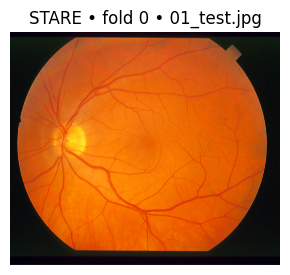

c:\Users\s1005\OneDrive\文件\PLM_DOCS\code\githubs\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\venv310\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[F00 E001] train=0.5435 val=0.3807 lr=1.20e-04 time=105.3s
	CHECKPOINT SAVED: ..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E002] train=0.3171 val=0.1941 lr=1.80e-04 time=106.5s
	CHECKPOINT SAVED: ..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E003] train=0.2060 val=0.1194 lr=2.40e-04 time=106.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E004] train=0.1677 val=0.1048 lr=3.00e-04 time=180.7s
	CHECKPOINT SAVED: ..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E005] train=0.1508 val=0.0929 lr=3.00e-04 time=156.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E006] train=0.1370 val=0.0778 lr=3.00e-04 time=164.8s
	CHECKPOINT SAVED: ..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth
[F00 E007] train=0.1322 val=0.0856 lr=2.99e-04 time=184.2s
[F00 E008] train=0.1295 val=0.0710 lr=2.97e-04 time=170.9s
	CHECK

In [ ]:
all_metrics, summary = run_stare_loo_experiment(
    root=DATASET_ROOT,
    label_folder=DATASET_LABELFOLDER,
    epochs=EPOCHS,
    warmup=warmup_epochs,
    batch_size=2,
    img_size=IMG_SIZE,
    patch_train=True,
    patch_size=PATCH_SIZE,
    vessel_bias_p=VESSEL_BIAS,
    threshold_eval=THRESHOLD_EVAL,
    folds=FOLDS,
    fold_id=0,   #starts at any fold_id

    chckpnt_paths= [
        # "..\..\..\..\pth\FR-UNet_STARE_NEWSPLIT\checkpoints\STARE_fold00.pth"
    ]
)
